# Modulo links and references

As usual let's make sure we have py5canvas ready in the cells

In [21]:
from py5canvas import *

## Links
- [Golan Levin modulo explainer](https://www.youtube.com/watch?v=r5Iy3v1co0A)
- [Dave Whyte (BeesAndBombs)](https://www.tumblr.com/beesandbombs), nice procedural loops.
- Modulo math art
    - [Video: curves emerging from modulo on the circle](https://www.youtube.com/watch?v=qhbuKbxJsk8)
    - [Bridges conference](https://www.bridgesmathart.org) paper: [Naylor (2015) Math Bugs](https://archive.bridgesmathart.org/2015/bridges2015-137.pdf)
    - [Video: exploring prime number visualization in Python](https://youtu.be/03Uw0P08Mj4?si=VBHb4KfLBPU6BIW_)


## Modulo recap

The modulo `%` operator gives us the remainder after an integer division. For two values `a` and `b` it is the remainder of `floor(a/b)`, which in Python can be written more concisely as `a//b`. The value on the right is commonly referred to as the *divisor*.

In [24]:
a = 7
b = 5

print(a % b)
print(a - floor(a / b) * b)
print(a - (a // b) * b)

2
2
2


While this is not the case for all programming languages, in Python the `%` operator also works with floating point numbers. Try experimenting with the values `a` and `b` above.

One way to think about modulo is to think about counting on a circle. We are used to do so when looking at clocks, which typically represent the current time "modulo 12" that is `time%12`, or `time%24`. But using the modulo we replace the 12 or the 24 with zero, and this can be generalized to any divisor:

![alt text](modulo_files/image-2.png)

Another analogy we are used to is thinking about angles in degrees (`angle%360`) or radians (`angle%PI`)

![alt text](modulo_files/image.png)

## "Wrapping" graphics with 

One simple way to use modulo is to have an animated object appear on the one end of the canvas when it disappears on the other end, e.g.:

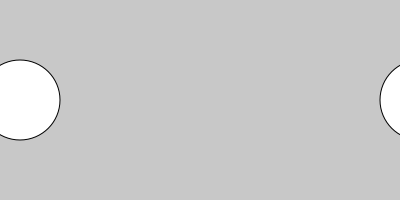

In [25]:
create_canvas(400, 200)
r = 40
x = 420
circle((x - r) % width + r,  height/2, r*2)
circle((x + r) % width - r,  height/2, r*2)
show()

In this example we draw two circles to display the wrapped part appearing on the other end of the canvas, as if we unwrapped the canvas from the surface of a 3D cylinder. 

![alt text](modulo_files/image-4.png)

A simpler but useful alternative, perhaps more practical for most animation purposes, is to use a range bigger than the canvas area, so that objects disappear completely, and then gradually reappear on the opposite side. This will not require drawing the same object multiple times as we did above.




>**LAB**:  The [wrap_loop.py](./wrap_loop.py) does exactly that:
> - Experiment with replacing the circles in the `draw_object` function. 
> - Try to create an animation inside `draw_object` using randomness. 
>    - To have predictable sequences of random numbers, call `random_seed` with a value of your choice at the beginning of `draw()`. 


## Making patterns with mod

Adapted from [this thread](https://discourse.processing.org/t/making-patterns-with-modulo/17522).

### 1A - Random pattern
We can make a simple horizontal random pattern like this

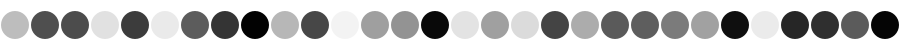

In [3]:
size(900, 50)
background(255)
no_stroke()
for x in range(30):
    fill(random(255))
    ellipse(x*30 + 15, 25, 28, 28)
show()

## 2A - Even odd pattern
So how can I avoid randomness and make a pattern? I’ll start by alternating two colors. To do that I will check if the current circle is odd or even, and choose a color accordingly. To do that, we will replace the line `fill(random(255))` with an if statement that checks if the remainder of `x//2` (note that `//` is the integer division in Python) is zero (even) or odd (one):

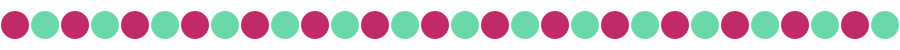

In [ ]:
size(900, 50)
background(255)
no_stroke()
for x in range(30):
    if x%2 == 0:
        fill("#C12969")
    else:
        fill('#6BD8AA')
    ellipse(x*30 + 15, 25, 28, 28)
show()

You could understand the expression `if x%2 == 0` as “if it is the first step in a loop of 2 steps…”. We could also write if `x%2 == 1` which would mean “if it is the second step in a loop of two steps” in case we wanted to target the second element.
In a loop of two steps it doesn’t make much sense because we can use the else case for that, but we will see later why this is useful in longer loops.

## 3A - Pattern of length 3

Back to our pattern. How to create a pattern like BCC BCC BCC BCC…? Simple:

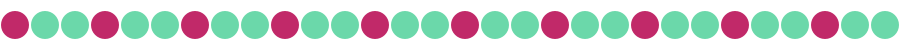

In [6]:
size(900, 50)
background(255)
no_stroke()
for x in range(30):
    if x%3 == 0:
        fill('#C12969')
    else:
        fill('#6BD8AA')
    ellipse(x*30 + 15, 25, 28, 28)
show()

## 4A - Pattern of length 4
Here we don't check the first element but the third (index 2)

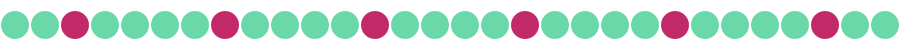

In [8]:
size(900, 50)
background(255)
no_stroke()
for x in range(30):
    if x%5 == 2:
        fill('#C12969')
    else:
        fill('#6BD8AA')
    ellipse(x*30 + 15, 25, 28, 28)
show()

## 5A - Not just one item per pattern

What else could we do? Maybe BBCCC BBCCC BBCCC? That looks like this:

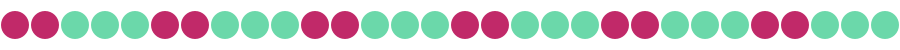

In [29]:
size(900, 50)
background(255)
no_stroke()
for x in range(30):
    if x%5 < 2:
        fill('#C12969')
    else:
        fill('#6BD8AA')
    ellipse(x*30 + 15, 25, 28, 28)
show()

How does this work? x%5 will always gives us one of these values: 0, 1, 2, 3 or 4. If we check if that value is less than 2, we get true for 0 and 1. That why the pattern looks like BBCCC BBCCC BBCCC.

## 6A - Two conditions

What about a slightly more complex one like BCBCC BCBCC BCBCC?
For that one we might want to check if we are dealing with item 0 or 2 in each loop.
Like this:

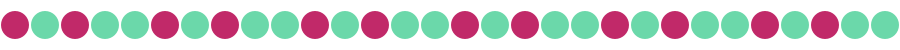

In [10]:
size(900, 50)
background(255)
no_stroke()
for x in range(30):
    if x%5 == 0 or x%5 == 2:
        fill('#C12969')
    else:
        fill('#6BD8AA')
    ellipse(x*30 + 15, 25, 28, 28)
show()

## 7A - Combine patterns

Looking at the last one might give us an idea for more strange patterns. What if instead of checking against two loops of length 5, we check against two loops of different lengths? This will give patterns that take longer to repeat. Like this one:

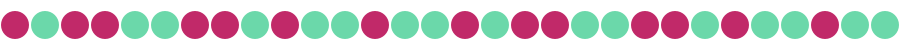

In [11]:
size(900, 50)
background(255)
no_stroke()
for x in range(30):
    if x%3 == 0 or x%5 == 2:
        fill('#C12969')
    else:
        fill('#6BD8AA')
    ellipse(x*30 + 15, 25, 28, 28)
show()

This loop will repeat every 15 steps because length_of_loop_1 x length_of_loop_2 = 15 (and both lengths are prime numbers). If we had lengths of 3 and 6 the total length would still be 6, not 18. If you are curious why I can explain it below.

## 1B - Now in 2D - randomness

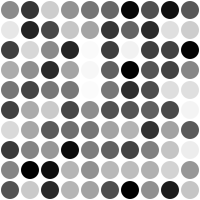

In [27]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        fill(random(255));
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

## 2B - First 2D pattern

If we use the old approach

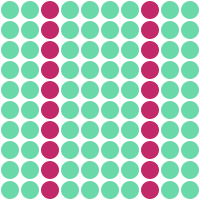

In [30]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        if x%5 == 2:
            fill('#C12969')
        else:
            fill('#6BD8AA')
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

there’s something missing. We do have a grid, but nothing changes in the vertical axis.

## 3B - Using both x and y

What if we take the approach from 7A and combine two patterns, one dealing with x and one dealing with y?

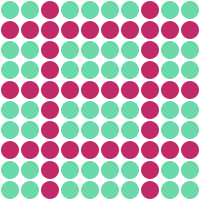

In [31]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        if x%5 == 2 or y%3 == 1:
            fill('#C12969')
        else:
            fill('#6BD8AA')
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

Ok, that’s better. So we have a horizontal pattern of length 5 looking like CCBCC and a vertical pattern of length 3 that looks like CBC. But it can be very “grid-like” for some tastes.

## 4B - Tilt it

What if we combine x and y in the same comparison? For this it’s important to put into parenthesis whatever expression we put into the modulo operation. `a+b%c` is no the same as `(a+b)%c`. In the first of these examples `b%c` is calculated first and then added to `a`.

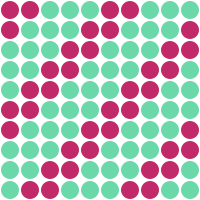

In [32]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        if (x+y)%5 < 2:
            fill('#C12969')
        else:
            fill('#6BD8AA')
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

## 5B - Using the cell index
More complex patterns can be achieved by knowing the index of the cell we are dealing with, so in this example of a grid of size 10x10, we would get an integer value between 0 and 99. How can we calculate that number? Simple:

```python
index = x + y * 10 # 10 is the width of the grid.
```
Now we can use index to decide the color, instead of `x` or `y`.

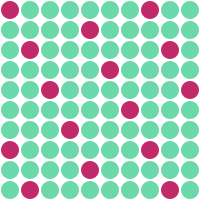

In [33]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        index = x + y * 10
        if index%7 == 0:
            fill('#C12969')
        else:
            fill('#6BD8AA')
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

The effect is like counting from the first cell in the grid to the last one and highlighting one every 7.

## 6B - Use the cell index twice
For added complexity, lets use the index twice:

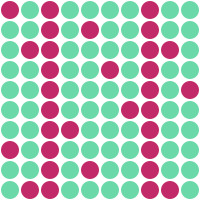

In [34]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        index = x + y * 10
        if index%7 == 0 or index%5 == 2:
            fill('#C12969')
        else:
            fill('#6BD8AA')
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

Now that I find very interesting because at this scale it seems to be somewhere between random and pattern.

## 7B - More colors
I’ll go back to using if statements for this one, as using two ternary operators in the same line gets quite unreadable:

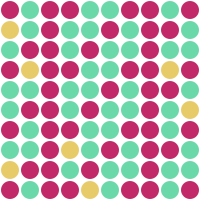

In [37]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        index = x + y * 10
        if index%3 == 0 or index%5 == 2:
            fill('#C12969')
        elif index%7 == 3:
            fill('#E8CB69')
        else:
            fill('#6BD8AA')
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

## 8B - Priorities
Note that changing the order of those conditions can alter the pattern. For example you can see that yellow has less priority than magenta because it’s the second condition. I’ll move yellow up to be the first condition:

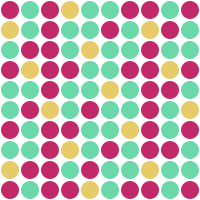

In [39]:
size(200, 200)
background(255)
no_stroke()
for x in range(10):
    for y in range(10):
        index = x + y * 10
        if index%7 == 3:
            fill('#E8CB69')
        elif index%3 == 0 or index%5 == 2:
            fill('#C12969')
        else:
            fill('#6BD8AA')
        ellipse(x*20 + 10, y*20 + 10, 18, 18)
show()

## Extra 1 - Varying size

Instead of discrete color changes, we can use the modulo operator to vary shape parameters, e.g. the diameter of a circle. For example using addition

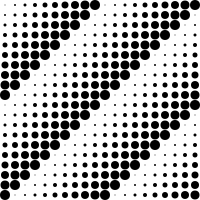

In [110]:
size(200, 200)
background(255)
no_stroke()
fill(0)
for x in range(20):
    for y in range(20):
        diameter = (x+y)%10 # Addition
        circle(x*10 + 5, y*10 + 5, 1+diameter) # py5canvas crashes if diameter is 0 (BUG to fix!)
show()

Multiplication

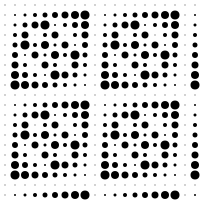

In [119]:
size(200, 200)
background(255)
no_stroke()
fill(0)
for x in range(20):
    for y in range(20):
        diameter = (x*y)%9 # Addition
        circle(x*10 + 5, y*10 + 5, 1+diameter) # py5canvas crashes if diameter is 0 (BUG to fix!)
show()

Or power (the `**` operator in Python, so `a**3` is `a*a*a`)

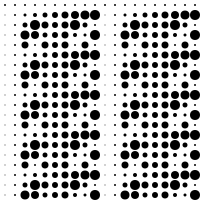

In [122]:
size(200, 200)
background(255)
no_stroke()
fill(0)
for x in range(20):
    for y in range(20):
        diameter = (x**y)%10 # Addition
        circle(x*10 + 5, y*10 + 5, 1+diameter) # py5canvas crashes if diameter is 0 (BUG to fix!)
show()

## Extra 2 - prime number fill

A bit more complex, we can use [prime numbers](https://www.palomar.edu/math/wp-content/uploads/sites/134/2018/02/A-Primer-on-Prime-Numbers.pdf) and modulo to fill a grid with a pattern. Here is a list of some prime numbers, you can get more from [here](https://www.math.uchicago.edu/~luis/allprimes.html): 

In [41]:
primes = [2, 3, 5, 7, 11, 13, 17, 19,
          23, 29, 31, 37, 41, 43, 47,
          53, 59, 61, 67, 71, 73, 79,
          83, 89, 97, 101, 103, 107,
          109, 113, 127, 131, 137, 139,
          149, 151, 157, 163, 167, 173,
          179, 181, 191, 193, 197, 199,
          211, 223, 227, 229, 233, 239,
          241, 251, 257, 263, 269, 271,
          277, 281, 283, 293, 307, 311,
          313, 317, 331, 337, 347, 353,
          359, 367, 373, 379, 383, 389,
          397, 401, 409, 419, 421, 431,
          433, 439, 443, 449, 457, 461,
          463, 467, 479, 487, 491, 499,
          503, 509, 521, 523, 541]

Now, for a `grid_size` times `grid_size` grid, if we create a loop using an index that counts until a number less than `grid_size*grid_size - 1` and compute the corresponding `x` and `y` cells wel can get patterns that vary depending on the prime number we choose:

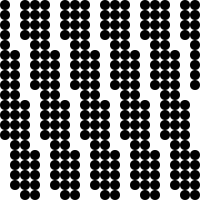

In [100]:
size(200, 200)
background(255)
no_stroke()
grid_size = 20
cell_size = width/grid_size
fill(0)
for i in range(grid_size*(grid_size-6)): # Setting grid_size*grid_size will cover all cells
    prime = primes[25]
    i = (i*prime)%(grid_size*grid_size) # Get index inside the grid
    # recover x and y from the index
    x = i % grid_size
    y = i // grid_size
    ellipse(x*cell_size + cell_size/2, y*cell_size + cell_size/2, cell_size, cell_size)
show()

Note that while earlier we recovered the index by doing `index = y*grid_size + x`, now we do the inverse. Assuming `i` is incrementing along each row, we have the `x`s restarting from zero at each row (`x = i % grid_size`) and the `y`s incrementing by one each row (`y = i // grid_size`). The `//` operation is "integer division" and is a specific feature of Python. This is a common pattern in programming and has many use-cases in addition to pattern generation!